# IMC Trading Challange

In [213]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

#import mplfinance as mpf
from pathlib import Path

## Loading Previous Data

In [96]:
# Data given to us of the previous two days

# Data is given as a folder, link to folder path
path = '/Users/hamedsedky/Downloads/TUTORIAL_ROUND_1'
files = list(Path(path).iterdir())

# Turn csv files into pandas DataFrame objects
dfs = [pd.read_csv(str(file), sep = ';') for file in files]

dfs[0]['day'] = -2
dfs[2]['day'] = -1

dfs[1]['day'] = -1
dfs[3]['day'] = -2

order_book = pd.concat([dfs[0], dfs[1]])
trades = pd.concat([dfs[2], dfs[3]])

# Add a time column, just to make is easier for us to understand
# the chronology of trades
trades['time'] = pd.to_datetime(
    trades.timestamp, unit = 'ms', origin = '2026-04-14'
)

# Remove unimportant columns
trades.drop(['buyer', 'seller', 'currency', 'timestamp'], axis = 1, inplace = True)

trades.set_index('time', inplace = True)

In [97]:
trades

,symbol,price,quantity,day
time,,,,
2026-04-14 00:00:03.200,EMERALDS,9992.0,8,-1
2026-04-14 00:00:03.400,TOMATOES,5009.0,2,-1
2026-04-14 00:00:05.000,EMERALDS,9992.0,7,-1
2026-04-14 00:00:07.000,TOMATOES,5010.0,4,-1
2026-04-14 00:00:09.600,TOMATOES,4999.0,5,-1
...,...,...,...,...
2026-04-14 00:16:26.100,TOMATOES,5002.0,5,-2
2026-04-14 00:16:28.600,TOMATOES,5004.0,5,-2
2026-04-14 00:16:29.300,TOMATOES,5017.0,2,-2


In [196]:
# Creating Open-High-Low-Close-Volume table

# Choose the time interval
interval = '10s'

ohlc = (
    trades
        .groupby('symbol')
        .resample(interval, include_groups = False)
        .agg(
            Open = ('price', 'first'),
            High = ('price', 'max'),
            Low = ('price', 'min'),
            Close = ('price', 'last'),
            Volume = ('quantity', 'sum')
        )
)

In [197]:
joint_index = ohlc.loc['TOMATOES'].index.union(ohlc.loc['EMERALDS'].index)
tomatoes = ohlc.loc['TOMATOES'].reindex(joint_index).ffill()
emeralds = ohlc.loc['EMERALDS'].reindex(joint_index).ffill()

## Experimenting with the Data

<Axes: xlabel='time'>

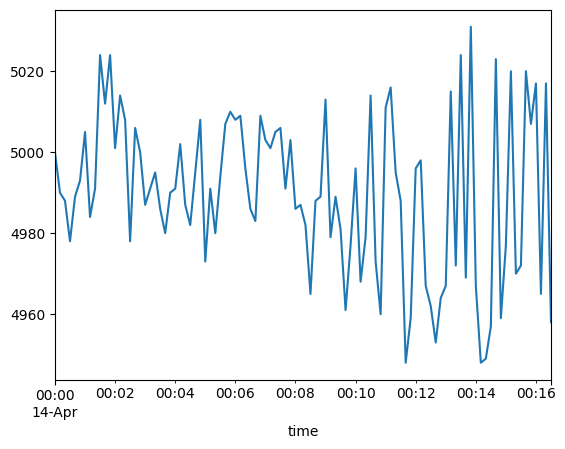

In [198]:
# Plot the price of TOMATOES over the trading days
tomatoes['Close'].plot()

<Axes: xlabel='time'>

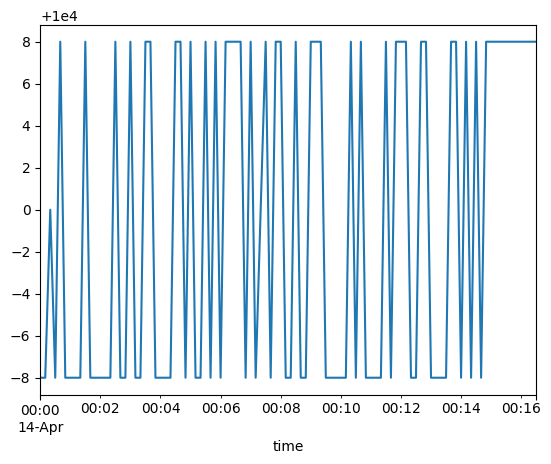

In [199]:
# Plot the price of EMERALDS over the trading days
emeralds['Close'].plot()

`TOMATOES` seem to behave like a normal stock, `EMERALDS` are a quite strange!

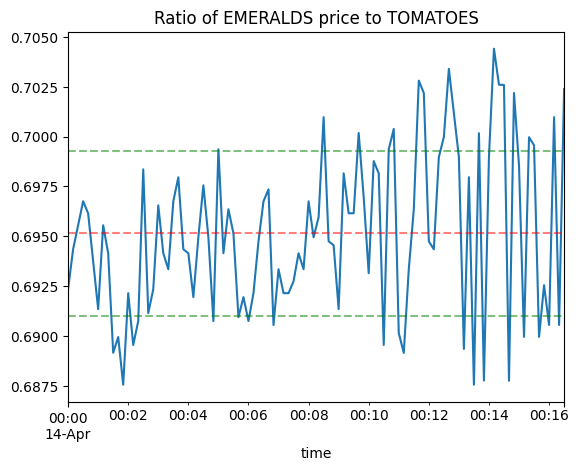

In [262]:
ratio = np.log(emeralds['Close']) - np.log(tomatoes['Close'])
ratio.plot()
plt.title('Ratio of EMERALDS price to TOMATOES');

m = ratio.mean()
s = ratio.std(ddof = 1)
plt.axline(xy1 = (0, m), slope = 0, c = 'r', ls = '--', alpha = 0.5)
plt.axline(xy1 = (0, m + s), slope = 0, c = 'g', ls = '--', alpha = 0.5)
plt.axline(xy1 = (0, m - s), slope = 0, c = 'g', ls = '--', alpha = 0.5)

Interestingly, the ratio between the price of `EMERALDS` to `TOMATOES` seems to be around 2x, is this something we could use?

ChatGPT suggested a statistical test to test if the ratio is mean reverting.

In [263]:
coint(np.log(tomatoes['Close']), np.log(emeralds['Close']))

(np.float64(-8.63130007759677),
 np.float64(7.60659977205887e-13),
 array([-4.01048603, -3.39854434, -3.08756793]))

In [264]:
# Regression
X = sm.add_constant(np.log(tomatoes['Close']))
model = sm.OLS(np.log(emeralds['Close']), X).fit()

beta = model.params['Close']
residuals = model.resid

# ADF test on residuals
adf_result = adfuller(residuals)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -9.52990122590698
p-value: 2.909671159602919e-16


Both tests imply this relationship is statisticaly significant, so this seems quite promising actually!

In [265]:
spread = np.log(emeralds['Close']) - beta * np.log(tomatoes['Close'])
z_score = (spread - spread.mean()) / spread.std()

<Axes: xlabel='time'>

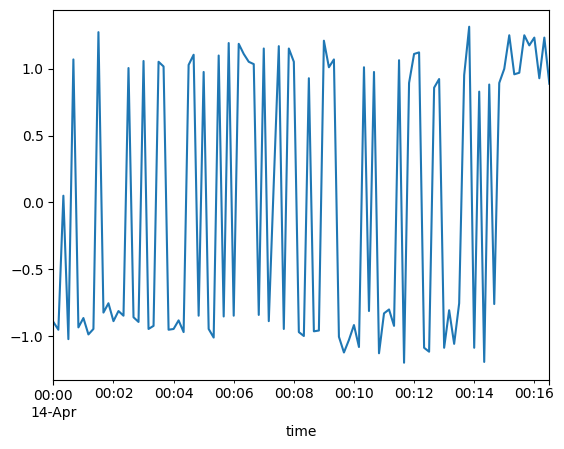

In [269]:
z_score.plot()

In [267]:
z_score.mean(), z_score.std()

(np.float64(-2.701128209992021e-13), 0.9999999999999999)

In [258]:
# lagged series
z_score_lag = z_score.shift(1).dropna()
z_score_now = z_score.loc[z_score_lag.index]

# regression: z_t = phi * z_{t-1} + error
model = sm.OLS(z_score_now, sm.add_constant(z_score_lag)).fit()
phi = model.params[1]

# half-life
half_life = -np.log(2) / np.log(abs(phi))

print("phi:", phi)
print("half-life:", half_life)

phi: 0.03295604610878751
half-life: 0.20311525900860702


/var/folders/sz/gskg31710872xdxq5kzfq6hc0000gn/T/ipykernel_9984/2285387987.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  phi = model.params[1]


In [259]:
from scipy.fft import fft

z_demeaned = z_score - z_score.mean()
fft_vals = fft(z_demeaned)

# frequencies
freqs = np.fft.fftfreq(len(z_demeaned))

# ignore zero frequency
idx = np.argmax(np.abs(fft_vals[1:])) + 1

dominant_freq = abs(freqs[idx])
period = 1 / dominant_freq

print("Dominant period:", period)

Dominant period: 50.0
